## Створення моделі передбачення суми донатів до кінця на основі банківської виписки за попередні місяці
**Вхідні дані:**
Ми працюємо з агрегованими місячними даними, які містять такі показники:

* total_amount – загальна сума надходжень за місяць

* n_transactions – кількість транзакцій

* sum_income – сума надходжень

* sum_expense – сума витрат

* income_share – частка надходжень у загальній сумі

**Ідея:**
Щоб передбачити майбутні надходження, ми використовуємо лагові ознаки (тобто значення попередніх місяців). Наприклад, total_amount_lag1 — це сума надходжень за минулий місяць, total_amount_lag2 — за два місяці до поточного тощо. Це дозволяє моделі враховувати тимчасові закономірності в даних.
Але спочатку ми пробуємо побудувати більш просту модель і впевнюємося в її поганій ефективності.

**Модель:**
Для моделювання ми використовуємо RandomForestRegressor зі sklearn — це ансамблевий метод на основі багатьох дерев рішень, який добре справляється з нелінійними залежностями та не вимагає масштабування даних.

**Прогнозування майбутніх місяців:**
Ми робимо пошагове (autoregressive) прогнозування: для кожного наступного місяця модель прогнозує значення, потім це значення використовується як вхід (лаг) для прогнозу ще наступного місяця. Цей підхід дозволяє передбачити кілька періодів вперед.

**Результат:**
У результаті ми отримуємо список прогнозів на n_forecast_months наперед. Це дозволяє оцінити тенденції майбутніх надходжень і використовувати ці дані для планування бюджету або фандрейзингової активності.

**Плюси:**
* Простий та гнучкий підхід
* Дає можливість враховувати структуру часу
* Можна додати багато додаткових фіч (сезонність, свята, дні тижня тощо)

**Обмеження:**
* Накопичення помилок при довгому прогнозі (оскільки нові прогнози базуються на старих)
* Не враховує сезонність напряму (на відміну від ARIMA чи Prophet) — але її можна вручну зашити в фічі (наприклад, month, is_holiday, is_end_of_year). Це до речі варіанти на тему, можна буде спробувати створити інші моделі.

### Завантажимо бібліотеки і дані

In [1]:
!pip install --upgrade numpy scikit-learn matplotlib pandas


In [2]:
# імпортуємо необхідні нам бібліотеки з якими будемо працювати
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from datetime import datetime

In [3]:
# зчитаємо наш файл з гугл диску і подивимось як він виглядає
df = pd.read_csv('drive/MyDrive/test/fake_bank_statement_1000csv.csv')

df.head()

,transaction_id,date,payment_type,amount,counterparty
0,TX-10000,2025-06-14,Комісія банку,-8272.55,Контрагент 3
1,TX-10001,2025-04-17,Цільове фінансування,1314.09,Контрагент 33
2,TX-10002,2025-03-25,Грантова підтримка,9528.63,Контрагент 40
3,TX-10003,2025-05-18,Благодійний внесок юрособа,6092.71,Контрагент 35
4,TX-10004,2025-06-21,Благодійний внесок юрособа,4789.33,Контрагент 13


### Аналіз і обробка данах

In [4]:
# Перевіримо типи даних, бо машинне навчання працює з цифрами або категоріями
df.info()

# Перевіримо унікальні payment_type
print(df['payment_type'].unique())

# Конвертуємо дату у datetime, бо дефолтне значення цієї колонки теж обʼєкт
df['date'] = pd.to_datetime(df['date'])

# Сортуємо по даті
df = df.sort_values('date')

df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1009 non-null   object 
 1   date            1009 non-null   object 
 2   payment_type    1009 non-null   object 
 3   amount          1009 non-null   float64
 4   counterparty    1009 non-null   object 
dtypes: float64(1), object(4)
memory usage: 39.5+ KB
['Комісія банку' 'Цільове фінансування' 'Грантова підтримка'
 'Благодійний внесок юрособа' 'Переказ між рахунками' 'Повернення коштів'
 'Відсотки на залишок' 'Благодійний внесок фізособа']


,transaction_id,date,payment_type,amount,counterparty
120,TX-10120,2025-01-01,Цільове фінансування,4489.89,Контрагент 16
700,TX-10700,2025-01-01,Комісія банку,-6183.83,Контрагент 37
353,TX-10353,2025-01-01,Відсотки на залишок,6169.47,Контрагент 4
929,TX-10929,2025-01-01,Переказ між рахунками,-7815.94,Контрагент 28
294,TX-10294,2025-01-01,Цільове фінансування,6598.91,Контрагент 25
...,...,...,...,...,...
884,TX-10884,2025-07-31,Грантова підтримка,1369.64,Контрагент 1
380,TX-10380,2025-07-31,Відсотки на залишок,2696.79,Контрагент 1
603,TX-10603,2025-07-31,Повернення коштів,-7054.56,Контрагент 37
480,TX-10480,2025-07-31,Цільове фінансування,8960.95,Контрагент 40


In [5]:
# Створимо колонку date_month
df['date_month'] = df['date'].dt.to_period('M').astype(str)
df.head()

,transaction_id,date,payment_type,amount,counterparty,date_month
120,TX-10120,2025-01-01,Цільове фінансування,4489.89,Контрагент 16,2025-01
700,TX-10700,2025-01-01,Комісія банку,-6183.83,Контрагент 37,2025-01
353,TX-10353,2025-01-01,Відсотки на залишок,6169.47,Контрагент 4,2025-01
929,TX-10929,2025-01-01,Переказ між рахунками,-7815.94,Контрагент 28,2025-01
294,TX-10294,2025-01-01,Цільове фінансування,6598.91,Контрагент 25,2025-01


In [6]:
# Cтворимо новий датасет(наша табличка) де ми агрегуємо(згрупуємо) наші дані по місяцях і додамо колонки з даними які нас цікавлять для створення моделі передбачення
df_monthly = df.groupby('date_month').agg({
    'amount': 'sum',
    'transaction_id': 'count',
    'counterparty': pd.Series.nunique,
    'payment_type': pd.Series.nunique
}).reset_index()

df_monthly.columns = ['date_month', 'net_income', 'num_transactions', 'num_unique_counterparties', 'num_unique_payment_types']

df_monthly

,date_month,net_income,num_transactions,num_unique_counterparties,num_unique_payment_types
0,2025-01,163975.99,151,49,8
1,2025-02,167481.10,143,46,8
2,2025-03,91795.30,129,45,8
3,2025-04,327808.25,148,49,8
4,2025-05,168411.45,141,46,8
5,2025-06,283660.40,159,48,8
6,2025-07,1767833.82,137,48,8
7,2025-12,8700.00,1,1,1


In [7]:
# Перетворимо місяць у числовий формат для моделі
df_monthly['month_number'] = pd.to_datetime(df_monthly['date_month']).dt.month

# Вибір X(ті колонки які ми аналізуємо і на які спираємось при побудові моделі) та y(наша мета)
features = ['month_number', 'num_transactions', 'num_unique_counterparties', 'num_unique_payment_types']
X = df_monthly[features]
y = df_monthly['net_income']

### Побудова простої моделі лінійної регресії

MAE: 1398813.4886071857


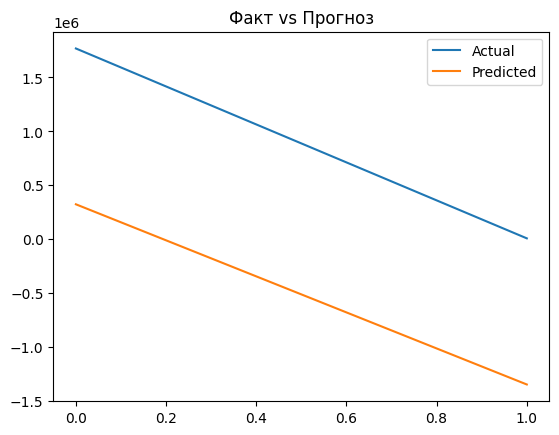

In [8]:
# Розділимо дані які ми маємо на тренувальні(на яких тренуємо модель) та дані на яких протестуємо результат
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Модель
model = LinearRegression()
model.fit(X_train, y_train)

# Прогноз
y_pred = model.predict(X_test)

# Оцінка
print("MAE:", mean_absolute_error(y_test, y_pred))

# Візуалізація
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('Факт vs Прогноз')
plt.show()

Як бачимо модель вийшла не дуже хорошою, занадто велика похибка. Тому далі ми спробуємо вдосконалити наш підхід і створити кращу модель.

### Покращення моделі для передбачення
Тут ми використаємо зовсім інший принцип побудови моделі.

**Ідея та статистичний принцип:**
Ми використали підхід часових рядів(Time Series) з лагами (lag features) + машинне навчання (Random Forest):

1. Лаги — це минулі значення:
Ми створили нові ознаки (features), які зберігають попередні значення колонок, наприклад:

* total_amount_lag1 — значення total_amount за попередній місяць

* total_amount_lag2 — значення два місяці тому


Так само ми створили лаги для:

* кількості транзакцій (n_transactions)

* доходів і витрат (sum_income, sum_expense)

* частки надходжень (income_share)

Це класичний підхід у статистиці для часових рядів, який дозволяє моделі вловлювати динаміку змін.

2. Random Forest як регресор
Random Forest — ансамбль дерев рішень, який:

* вміє працювати з нелінійними залежностями

* не потребує нормалізації

* добре обробляє багато ознак (features)

* не схильний до перенавчання (overfitting) завдяки своїй структурі

Ми "навчили" його передбачати `total_amount` за місяць на основі попередніх значень (лагів).

In [9]:
# Створюємо ознаки які є важливими для передбачення
monthly = df.groupby(df['date'].dt.to_period('M')).agg(
    total_amount=('amount', 'sum'),
    n_transactions=('amount', 'count'),
    n_unique_types=('payment_type', 'nunique'),
    n_unique_counterparties=('counterparty', 'nunique'),
    sum_income=('amount', lambda x: x[x > 0].sum()),
    sum_expense=('amount', lambda x: -x[x < 0].sum()),
    n_income=('amount', lambda x: (x > 0).sum()),
    n_expense=('amount', lambda x: (x < 0).sum()),
)

monthly['income_share'] = monthly['sum_income'] / (monthly['sum_income'] + monthly['sum_expense'])

# Перетворимо період у datetime
monthly.index = monthly.index.to_timestamp()
monthly = monthly.reset_index().rename(columns={"date": "month"})

# Видаляємо "дивний" рядок грудня, де одна транзакція, так як ми робимо передбачення до кінця року будемо вважати що у нас є дані по липегь включно і цей один запис з грудня просто випадковий
monthly = monthly[monthly['n_transactions'] > 1]

monthly


,month,total_amount,n_transactions,n_unique_types,n_unique_counterparties,sum_income,sum_expense,n_income,n_expense,income_share
0,2025-01-01,163975.99,151,8,49,449967.83,285991.84,95,56,0.611403
1,2025-02-01,167481.10,143,8,46,466208.86,298727.76,89,54,0.609474
2,2025-03-01,91795.30,129,8,45,358072.44,266277.14,74,55,0.573513
3,2025-04-01,327808.25,148,8,49,543192.97,215384.72,100,48,0.716068
4,2025-05-01,168411.45,141,8,46,427199.96,258788.51,87,53,0.622751
5,2025-06-01,283660.40,159,8,48,531225.60,247565.20,100,59,0.682116
6,2025-07-01,1767833.82,137,8,48,2007222.67,239388.85,92,45,0.893444


In [10]:
monthly['month'] = pd.to_datetime(monthly['month'])
monthly = monthly.sort_values('month')
monthly = monthly.set_index('month')

# Перевіримо
print(monthly.tail())

            total_amount  n_transactions  n_unique_types  \
month                                                      
2025-03-01      91795.30             129               8   
2025-04-01     327808.25             148               8   
2025-05-01     168411.45             141               8   
2025-06-01     283660.40             159               8   
2025-07-01    1767833.82             137               8   

            n_unique_counterparties  sum_income  sum_expense  n_income  \
month                                                                    
2025-03-01                       45   358072.44    266277.14        74   
2025-04-01                       49   543192.97    215384.72       100   
2025-05-01                       46   427199.96    258788.51        87   
2025-06-01                       48   531225.60    247565.20       100   
2025-07-01                       48  2007222.67    239388.85        92   

            n_expense  income_share  
month                 

In [11]:
# створимо лаги для важливих ознак
lags = [1, 2, 3]
for col in ['total_amount', 'n_transactions', 'sum_income', 'sum_expense', 'income_share']:
    for lag in lags:
        monthly[f'{col}_lag{lag}'] = monthly[col].shift(lag)

# Після лагів — дропнемо перші 3 місяці (там будуть NaN)
monthly_lagged = monthly.dropna().copy()

In [12]:
# Train: до липня включно
train = monthly_lagged[:'2025-07']
# Наша задача передбачити серпень — грудень
n_forecast_months = 5

In [13]:
from sklearn.ensemble import RandomForestRegressor

features = [col for col in monthly_lagged.columns if 'lag' in col]
target = 'total_amount'

# Створюємо і тренуємо модель
model = RandomForestRegressor(random_state=42)
model.fit(train[features], train[target])

# Зберігаємо результати
predictions = []

last_row = train.iloc[-1:].copy()

# Цикл який пройдеться по усім місяцям які ми хочемо передбачити, а їх n_forecast_months = 5
for i in range(n_forecast_months):
    # Прогноз
    y_pred = model.predict(last_row[features])[0]

    # Створення нової дати
    next_month = last_row.index[0] + pd.DateOffset(months=1)

    # Сформуємо новий рядок
    new_row = last_row.copy()
    new_row.index = [next_month]
    new_row['total_amount'] = y_pred

    # Оновлюємо лагові фічі
    for lag in lags:
        for col in ['total_amount', 'n_transactions', 'sum_income', 'sum_expense', 'income_share']:
            if lag == 1:
                new_row[f'{col}_lag{lag}'] = last_row[col].values[0]
            else:
                new_row[f'{col}_lag{lag}'] = last_row[f'{col}_lag{lag-1}'].values[0]

    # Додаємо в predictions
    predictions.append((next_month, y_pred))

    # Переходимо до наступного місяця
    last_row = new_row


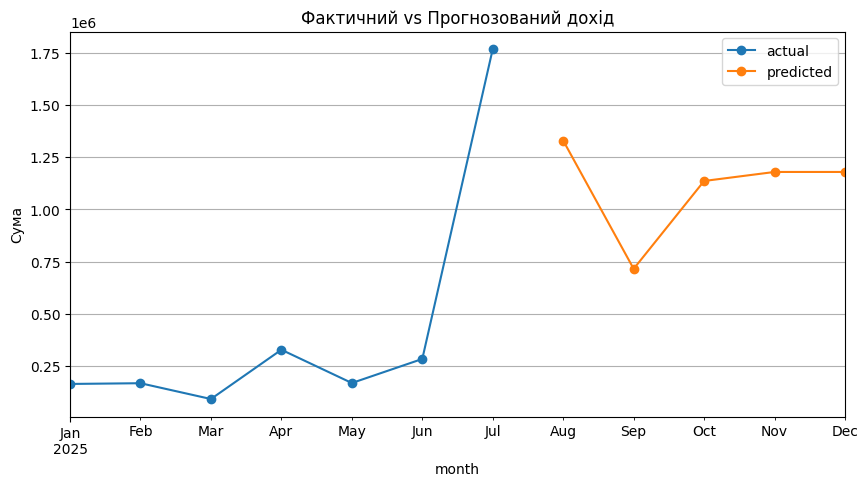

In [14]:
# Створюємо датафрейм з прогнозами
pred_df = pd.DataFrame(predictions, columns=['month', 'predicted_total_amount'])
pred_df.set_index('month', inplace=True)

# З'єднаємо з реальними
actual = monthly['total_amount']
combined = pd.concat([actual, pred_df['predicted_total_amount']], axis=1)
combined.columns = ['actual', 'predicted']

# Графік
combined.plot(figsize=(10, 5), marker='o')
plt.title("Фактичний vs Прогнозований дохід")
plt.grid(True)
plt.ylabel("Сума")

# Зберегти у файл PNG
plt.savefig('forecast_plot.png', dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
# Зберігаємо цю картнку собі
from google.colab import files
files.download('forecast_plot.png')

Далі подається більш детальний звіт які саме фічі(тобто показники) і наскільки сильно повпливали на передбачення нової моделі(щось більше впливає, щось менше).
Я не буду вдаватись тут до детального пояснення і розшифровки, це можна буде зробити за необхідності. В наявних даних у нас не так багато фіч і вцілому впливає все.

In [ ]:
import shap

explainer = shap.Explainer(model, train[features])
shap_values = explainer(train[features])

shap.plots.beeswarm(shap_values, max_display=10)

In [ ]:
# Створення Explainer
explainer = shap.Explainer(model, train[features])
shap_values = explainer(train[features])

# Бар-графік: середній абсолютний SHAP-вплив
shap.plots.bar(shap_values, max_display=10)